# 3.2 Memory and the cost of long rollouts

Reverse-mode differentiation has a hidden ledger. To run the chain rule backward, it
must revisit the forward computation in reverse order — which means the intermediate
states of the entire integration must be available, stored or recomputed. A simulation
that runs comfortably forward can therefore be undifferentiable in practice: the
forward model needs memory for one time step; its adjoint, naively, for all of them.

For the 60-point model used here this costs megabytes and is invisible. For an
atmosphere at kilometer resolution it is the difference between feasible and not. This
chapter measures the scaling, applies the standard cure — **checkpointing**, the
compute-for-memory trade formalized by Griewank {cite}`griewank2008evaluating` — and
ends with the elegant special case where the whole problem disappears: differentiating
a steady state.

```{admonition} Learning goals
:class: tip
- Explain why reverse mode stores the trajectory and how its memory scales
- Measure adjoint memory with JAX's compiled memory analysis
- Apply per-step rematerialization and two-level (square-root) checkpointing
- Differentiate an equilibrium via the implicit function theorem, with no stored trajectory
```

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)   # climate work needs double precision
# Running on Colab? First run:  %pip install -q optax equinox diffrax

In [2]:
# --- The Budyko-Sellers model (defined in Chapter 2.1; repeated so this notebook is self-contained)
N_LAT = 60
x_edge = jnp.linspace(-1.0, 1.0, N_LAT + 1)      # cell edges in x = sin(latitude)
x = 0.5 * (x_edge[:-1] + x_edge[1:])             # cell centres (an equal-area grid)
dx = 2.0 / N_LAT
lat = jnp.rad2deg(jnp.arcsin(x))                 # centre latitudes (degrees)

Q = 340.25              # global-mean insolation S0/4, W m^-2
s_x = 1.0 - 0.482 * 0.5 * (3.0 * x**2 - 1.0)     # annual-mean insolation shape s(x)
A_olr = 203.3           # outgoing longwave radiation at 0 degC, W m^-2
B_olr = 2.09            # longwave feedback, W m^-2 K^-1
heat_capacity = 4.0e7   # J m^-2 K^-1 (~10 m of water)
dt = 21600.0            # 6-hour time step, s

default_params = {"D": 0.48, "albedo_warm": 0.32, "albedo_ice": 0.62}

def albedo(T, p):
    ice_fraction = 0.5 * (1.0 - jnp.tanh((T + 10.0) / 2.0))    # ice below about -10 degC
    return p["albedo_warm"] + (p["albedo_ice"] - p["albedo_warm"]) * ice_fraction

def energy_tendency(T, p, forcing=0.0):
    """Net energy input at each latitude (W m^-2), for temperature T in degC."""
    absorbed = Q * s_x * (1.0 - albedo(T, p))
    emitted = A_olr + B_olr * T
    flux = p["D"] * (1.0 - x_edge[1:-1] ** 2) * jnp.diff(T) / dx   # poleward heat flux
    flux = jnp.concatenate([jnp.zeros(1), flux, jnp.zeros(1)])     # no flux through the poles
    transport = jnp.diff(flux) / dx
    return absorbed - emitted + transport + forcing

def integrate(T0, p, forcing=0.0, n_years=30):
    """Step the model forward and return the final temperature profile."""
    n_steps = int(n_years * 365.25 * 86400 / dt)
    def step(T, _):
        return T + dt / heat_capacity * energy_tendency(T, p, forcing), None
    T_final, _ = jax.lax.scan(step, T0, None, length=n_steps)
    return T_final

T_start = 15.0 - 25.0 * 0.5 * (3.0 * x**2 - 1.0)    # smooth warm initial profile

## Measuring the ledger

JAX can report the temporary memory a compiled function will allocate, before running
it. The function below builds a differentiated rollout of the Budyko–Sellers model
(the Part 2 model, redefined in the hidden cell above) in three variants and asks the
compiler for its scratch-space budget:

steps     forward   grad      grad+remat  grad+chunked
  1000     0.002      1.43        0.48       0.064   MB
  4000     0.002      5.73        1.92       0.125   MB
 16000     0.002     22.91        7.68       0.245   MB
 64000     0.002     91.65       30.72       0.487   MB


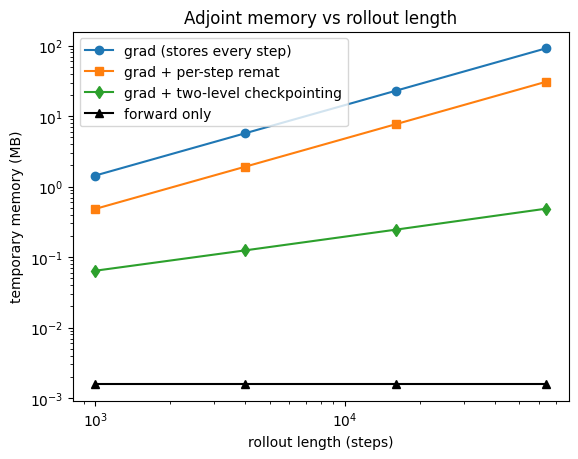

In [3]:
def rollout_loss(n_steps, variant="plain"):
    """Mean-square final temperature after n_steps, as a function of diffusivity."""
    def loss(D):
        p = dict(default_params, D=D)
        step = lambda T: T + dt / heat_capacity * energy_tendency(T, p)
        if variant == "remat":
            step = jax.checkpoint(step)
        if variant == "chunked":
            chunk = int(n_steps ** 0.5)
            @jax.checkpoint
            def inner(T):
                T, _ = jax.lax.scan(lambda t, _: (step(t), None), T, None, length=chunk)
                return T
            T, _ = jax.lax.scan(lambda t, _: (inner(t), None), T_start, None,
                                length=n_steps // chunk)
        else:
            T, _ = jax.lax.scan(lambda t, _: (step(t), None), T_start, None, length=n_steps)
        return jnp.mean(T ** 2)
    return loss

def temp_memory_mb(fn):
    compiled = jax.jit(fn).lower(jnp.float64(0.48)).compile()
    return compiled.memory_analysis().temp_size_in_bytes / 1e6

steps = [1000, 4000, 16000, 64000]
table = {v: [temp_memory_mb(jax.grad(rollout_loss(n, v))) for n in steps]
         for v in ["plain", "remat", "chunked"]}
fwd = [temp_memory_mb(rollout_loss(n)) for n in steps]

print("steps     forward   grad      grad+remat  grad+chunked")
for i, n in enumerate(steps):
    print(f"{n:6d}   {fwd[i]:7.3f}   {table['plain'][i]:7.2f}   {table['remat'][i]:9.2f}"
          f"   {table['chunked'][i]:9.3f}   MB")

plt.loglog(steps, table["plain"], "o-", label="grad (stores every step)")
plt.loglog(steps, table["remat"], "s-", label="grad + per-step remat")
plt.loglog(steps, table["chunked"], "d-", label="grad + two-level checkpointing")
plt.loglog(steps, fwd, "k^-", label="forward only")
plt.xlabel("rollout length (steps)"); plt.ylabel("temporary memory (MB)")
plt.legend(); plt.title("Adjoint memory vs rollout length")
plt.show()

Four regimes, one story:

- **Forward only** is flat: a time-stepper needs the current state and nothing else.
- **Plain `grad`** grows linearly — every step's state is saved for the backward pass.
  Sixty-four thousand steps of this toy already book ~90 MB; scale the state by the
  size of a GCM field and the wall arrives quickly.
- **Per-step rematerialization** (`jax.checkpoint` on the step function) tells JAX to
  discard each step's *internal* intermediates and recompute them during the backward
  pass. It cuts the constant (~3× here) but not the slope: the per-step states
  themselves must still be kept.
- **Two-level checkpointing** changes the slope. Split $N$ steps into $\sqrt{N}$
  chunks of $\sqrt{N}$: store only chunk boundaries, and recompute inside one chunk
  at a time during the backward sweep. Memory drops to $O(\sqrt{N})$ — a 188× saving
  at 64,000 steps — for roughly one extra forward pass of compute. Recursive
  (binomial) schedules push this to logarithmic memory; `diffrax` (Chapter 3.4)
  implements them for you.

The knob to remember: `jax.checkpoint` placed around a *scan body* controls what is
stored across the loop, and nesting scans sets the storage granularity.

## Steady states: sidestep the trajectory entirely

When the quantity of interest is an *equilibrium*, the trajectory that reached it is
scaffolding — and there is a way to differentiate that never stores it. At a steady
state, the energy tendency vanishes: $\mathcal{F}(T^\*, \theta) = 0$. Differentiating
this identity (the **implicit function theorem**) gives the sensitivity of the
equilibrium directly:

$$\frac{\partial T^\*}{\partial \theta}
= -\Bigl(\frac{\partial \mathcal{F}}{\partial T}\Bigr)^{-1}
\frac{\partial \mathcal{F}}{\partial \theta},$$

one linear solve against the Jacobian at the equilibrium, however long the spin-up
took. In JAX this is expressed by attaching a *custom derivative rule* to the spin-up
function — forward pass unchanged, backward pass replaced by the linear solve:

In [4]:
@jax.custom_vjp
def equilibrium(D):
    return integrate(T_start, dict(default_params, D=D), n_years=60)

def equilibrium_fwd(D):
    T_eq = equilibrium(D)
    return T_eq, (T_eq, D)

def equilibrium_bwd(saved, dLdT):
    T_eq, D = saved
    residual = lambda T, D: energy_tendency(T, dict(default_params, D=D))
    dF_dT = jax.jacobian(residual, argnums=0)(T_eq, D)      # 60x60 Jacobian
    dF_dD = jax.jacobian(residual, argnums=1)(T_eq, D)
    adjoint = jnp.linalg.solve(dF_dT.T, dLdT)               # one linear solve
    return (-adjoint @ dF_dD,)

equilibrium.defvjp(equilibrium_fwd, equilibrium_bwd)

g_implicit = jax.grad(lambda D: jnp.mean(equilibrium(D)))(0.48)
g_unrolled = jax.grad(lambda D: jnp.mean(integrate(T_start,
                      dict(default_params, D=0.0 + D), n_years=60)))(0.48)
print(f"d(global-mean T_eq)/dD   implicit: {float(g_implicit):.6f}")
print(f"d(global-mean T_eq)/dD   unrolled: {float(g_unrolled):.6f}")

d(global-mean T_eq)/dD   implicit: 61.652069
d(global-mean T_eq)/dD   unrolled: 61.652065


The two agree to seven digits — but the implicit version's backward pass is one
60×60 linear solve, independent of whether the spin-up took 60 years or 60,000. The
same idea, packaged, appears as `jax.lax.custom_root` and as the `optimistix`/
`diffrax` libraries' implicit differentiation of solvers and root-finders (Chapter
3.4). It applies whenever the output satisfies an equation — equilibria, implicit time
steps, optimization inner loops — and it is the cleanest large-scale memory fix
available: no trajectory, no checkpoints, exact gradient.

Two caveats for practice. The equilibrium must actually be reached (the identity
differentiated is $\mathcal{F}=0$; a half-spun-up state gives a subtly wrong
gradient), and for large states the explicit Jacobian is replaced by matrix-free
linear solves — the mathematics is unchanged.

**Exercises.**
1. At 64,000 steps, time (rather than measure memory for) the plain and chunked
   gradients. How much compute did the 188× memory saving cost?
2. Implement three-level checkpointing (nest one more scan). Predict the memory
   scaling before you measure it.
3. The implicit gradient needs $\partial\mathcal{F}/\partial T$ to be invertible.
   What does a singular Jacobian mean physically? (Chapter 1.3's fold is the answer.)